# **About Dataset**
## **1. Context**

It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

## **2. Content**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

# **About this notebook**
## **1. Overall**
- In this section, we load and explore the dataset at a high level. We examine the structure of the data, check for missing values, and understand the class distribution (fraudulent vs. legitimate transactions). The dataset contains 284,807 transactions with 492 fraud cases. Key insights include:

    + Dataset composition: 99.83% legitimate transactions, 0.17% fraudulent transactions
    + Features: 28 PCA-transformed features (V1-V28), plus Time and Amount columns
    + Target variable: Class (0 = legitimate, 1 = fraud)
- This imbalance means we can't simply train a standard classifier, as it would be biased toward predicting "not fraud" for everything.
## **2. EDA**
- Here we dive deeper into understanding the characteristics of fraudulent vs. legitimate transactions. We analyze:

    + Transaction amounts: How do fraud and legitimate transaction amounts differ?
    + Feature correlations: Which features are most strongly correlated with fraud?
    + Distribution patterns: Visualizations (boxplots, violin plots, heatmaps) reveal that fraud transactions tend to have different statistical properties than legitimate ones
- This exploratory phase helps us understand what signals in the data might help distinguish fraud from legitimate activity.

## **3. Preprocessing**
- Before training models, we prepare the data for machine learning:

    + Outlier detection: Using the IQR (Interquartile Range) method, we identify and remove extreme outliers that could distort model training
- This step is critical because outliers and unscaled features can negatively impact model performance.

## **4. Sampling methods**
- Since we have a severe class imbalance (0.17% fraud), we need techniques to balance the training data. This section compares five different sampling approaches:

    1. Random Under-Sampling (RUS): Randomly removes majority class samples to match minority class size
    2. NearMiss: Removes majority class samples that are closest to minority class samples
    3. Random Over-Sampling (ROS): Randomly duplicates minority class samples
    4. SMOTE (Synthetic Minority Over-Sampling Technique): Creates synthetic (artificial) fraud samples by interpolating between existing fraud transactions
    5. SMOTE + Tomek Links: Combines SMOTE with Tomek Links (removes noisy majority class samples)
- Each method is tested with visualization of class balance and t-SNE projections to understand how the data looks after resampling.

## **5. Model training**
- This section builds and compares multiple machine learning models, each tested with different sampling strategies. We train:

    + Logistic Regression: A simple, interpretable linear classifier
    + Stochastic Gradient Descent (SGD): A scalable linear classifier
    + Linear SVC: A support vector machine for linear classification
    + Random Forest: An ensemble method combining multiple decision trees
- For each model, we test five variations:

    + Baseline (no sampling, with class weighting)
    + Random Over-Sampling
    + Random Under-Sampling
    + NearMiss
    + SMOTE-Tomek (combination method)

- Hyperparameter tuning is performed using GridSearchCV to find the best parameters for each model-sampling combination. The models are evaluated using Average Precision (a metric suitable for imbalanced data), along with recall, precision, and F1-score.
- Results comparison: All model performances are compiled into a results table, sorted by recall and F1-score to identify which combination performs best.

## **6. Explainable AI (SHAP)**

- After training, we will select the bêst model from section 5 and apply SHAP to it:
    + SHAP Summary Plot (Bar): Shows the global feature importance across all predictions
    + SHAP Dependence Plots: Illustrates how feature values influence model output for top features
    + SHAP Force Plots: Individual prediction explanations showing how features push the prediction toward fraud or legitimate
    + SHAP Decision Plots: Visualizes the decision-making process across multiple samples
- We also provide some key insights from SHAP Analysis

## **7. Threshold Tunning for best model**
1. Model Evaluation
- We visualize the best-performing models using three diagnostic plots:

    + Learning curves: Show how model performance improves with more training data
    + Confusion matrix: Displays true positives, false positives, true negatives, and false negatives
    + Precision-Recall curve: Shows the trade-off between catching fraud (recall) and avoiding false alarms (precision)
- These visualizations help us understand model behavior and whether it generalizes well.
- The best model will be chosen for threshold tunning

2. Threshold Tuning
- This is a critical step for fraud detection. By default, classifiers predict fraud if the probability is > 0.5. However, for fraud detection, we often want to be more aggressive:

    + Lower threshold (e.g., 0.3): Catches more fraud but has more false alarms
    + Higher threshold (e.g., 0.7): Fewer false alarms but misses more fraud
- In this section, we test thresholds from 0.1 to 0.9 and measure how recall, precision, and F1-score change. This allows us to choose a threshold that matches business requirements—whether we prioritize catching all fraud or minimizing customer inconvenience from false positives.

## **8. Conclusion**

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import NearMiss, RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve
from sklearn.manifold import TSNE

import warnings
import time
warnings.filterwarnings("ignore")

import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.48.0


# I. Overall

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv'

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
pd.DataFrame(df.isnull().sum())

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df_fraud = df[df['Class'] == 1]
df_non_fraud = df[df['Class'] == 0]
no_fraud_pct = (len(df_non_fraud) / len(df)) * 100
fraud_pct = (len(df_fraud) / len(df)) * 100

print('No Frauds', round(no_fraud_pct, 2), '% of the dataset')
print('Frauds', round(fraud_pct,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: Legitimate || 1: Fraud)')

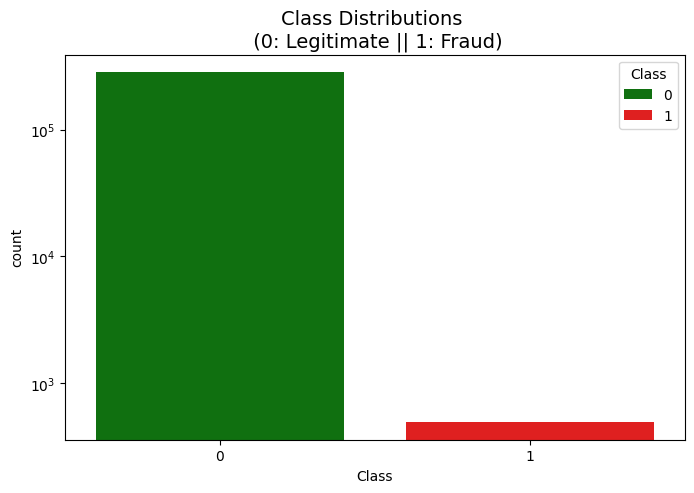

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (8, 5))
# Categorical plot: count of observations in each category(x): Fraud/Not Fraud
sns.countplot(x='Class', data=df, palette=['green', 'red'], hue = 'Class', ax = ax)
ax.set_yscale('log')
ax.minorticks_off()
plt.title('Class Distributions \n (0: Legitimate || 1: Fraud)', fontsize=14)

# II. EDA

In [ ]:
print("\nAmount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe().round(2))


Amount Statistics by Class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


## Comments
- Legitimate transactions: Median of $22.00, tightly concentrated in the $5.65–$77.05 range (IQR)
- Fraudulent transactions: Median of $9.25, with a much wider interquartile range ($1.00–$105.89)
- Mean values: Fraud average ($122.21) is 38% higher than legitimate average ($88.29), driven by large outliers

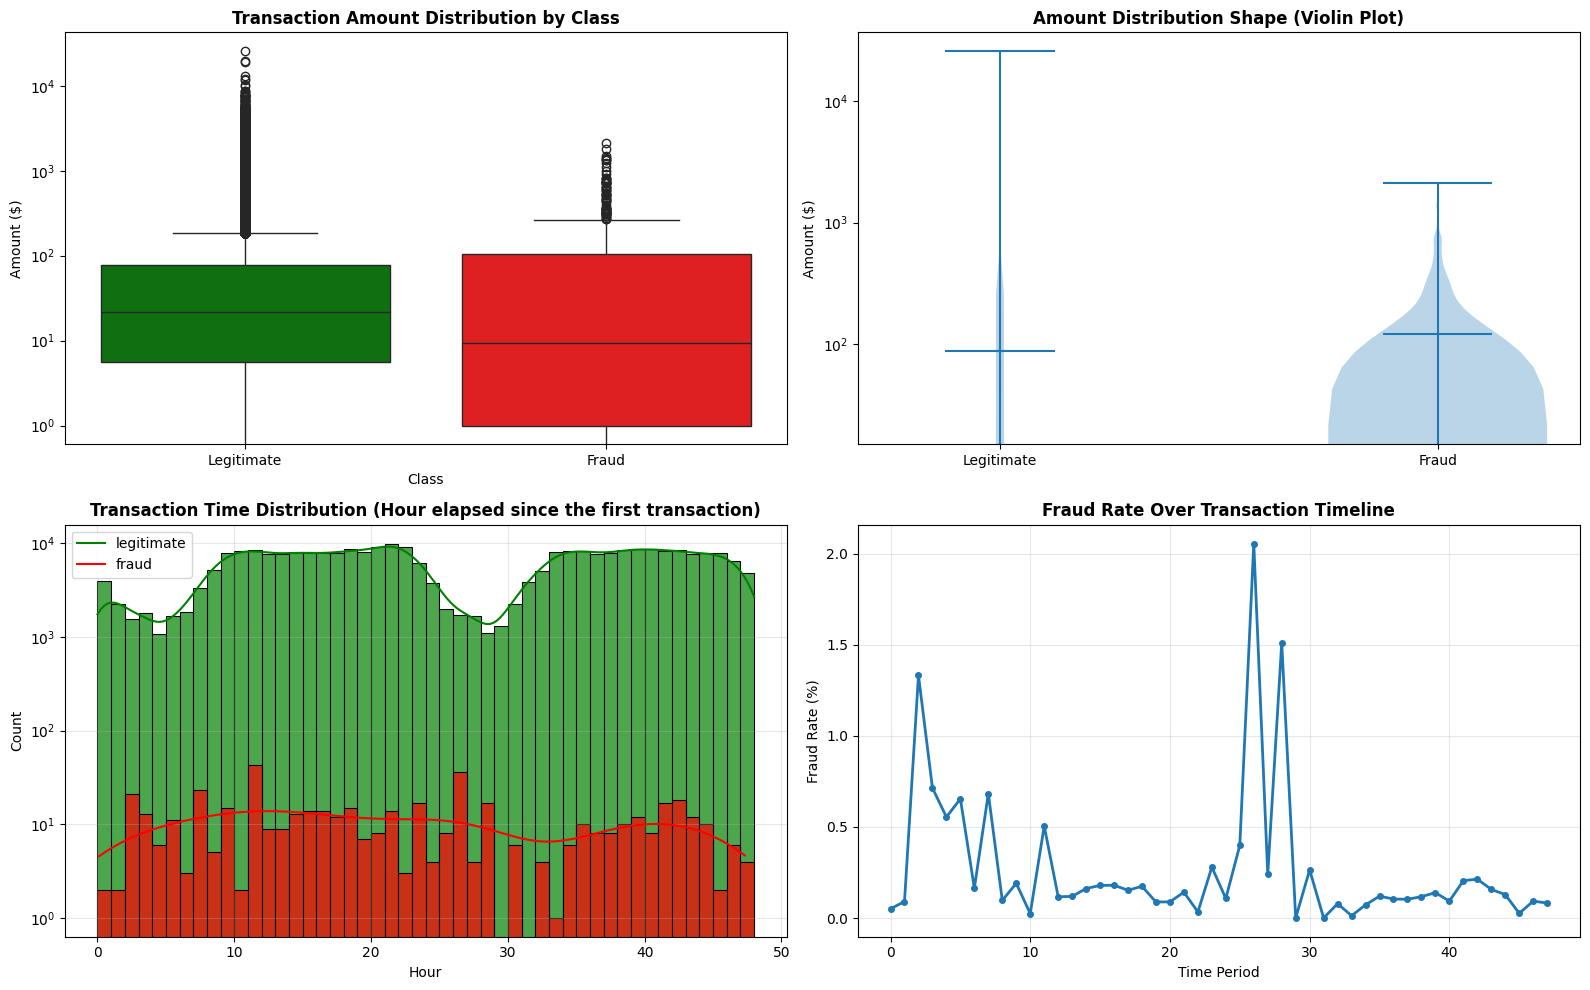

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
# Amount by Class - Boxplot
ax = axes[0, 0]
sns.boxplot(data = df, y='Amount', x='Class', ax=ax, palette = ['green', 'red'])
ax.set_title('Transaction Amount Distribution by Class', fontweight='bold')
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_ylabel('Amount ($)')
ax.set_xlabel('Class')
ax.set_yscale('log')
ax.minorticks_off()
 
# Amount by Class - Violin plot (better for skewed distributions)
ax = axes[0, 1]
df_fraud = df[df['Class'] == 1]['Amount']
df_legit = df[df['Class'] == 0]['Amount']
parts = ax.violinplot([df_legit, df_fraud], positions=[0, 1], showmeans=True)
ax.set_title('Amount Distribution Shape (Violin Plot)', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_ylabel('Amount ($)')
ax.set_yscale('log')
ax.minorticks_off()
 
# Time distribution (convert to hours)
bins = np.linspace(0, 48, 49)
ax = axes[1, 0]
df['Time_hours'] = (df['Time'] / 3600) % 48
df_time_legit = df[df['Class'] == 0]['Time_hours']
df_time_fraud = df[df['Class'] == 1]['Time_hours']
sns.histplot(df_time_legit, ax=ax, color='green', kde=True, bins = bins, alpha=0.7)
sns.histplot(df_time_fraud, ax=ax, color='red', kde=True, bins = bins, alpha=0.7)
ax.set_title('Transaction Time Distribution (Hour elapsed since the first transaction)', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(['legitimate', 'fraud'])
ax.grid(alpha=0.3)
ax.minorticks_off()
 
# Fraud rate over time
ax = axes[1, 1]
time_bins = pd.cut(df['Time'], bins=48)
fraud_rate_by_time = df.groupby(time_bins)['Class'].agg(['sum', 'count'])
fraud_rate_by_time['fraud_rate'] = (fraud_rate_by_time['sum'] / fraud_rate_by_time['count'] * 100)
ax.plot(range(len(fraud_rate_by_time)), fraud_rate_by_time['fraud_rate'], marker='o', linewidth=2, markersize=4)
ax.set_title('Fraud Rate Over Transaction Timeline', fontweight='bold')
ax.set_xlabel('Time Period')
ax.set_ylabel('Fraud Rate (%)')
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

## Comments 
1. Transaction Amount Distribution by Class
    - The violin plot shows that legitimate transactions cluster heavily around low amounts with a long tail, while fraud amounts are more dispersed with two distinct peaks (small opportunistic fraud and large fraudulent attempts).
    - But the boxplot showed that using transaction amount alone would be insufficient for fraud detection because:
        + Overlap in the $5–$100 range makes it hard to separate classes by amount alone
        + A rule like "flag all transactions > $100" would miss 75% of fraud AND generate many false positives
2. Transaction Time Distribution & Fraud Rate Over Timeline
    - According to the description of dataset, we don't know if the first transaction was recorded at 0h (begining of the day) or not, so we can't analyze the behaviour of fraudulent transactions base on date time.
    - However, we can see that the fraudulent transactions spreaded throughout 48 hours.
    - The fraud rate spikes between 0.1% and 2.1% over the period.

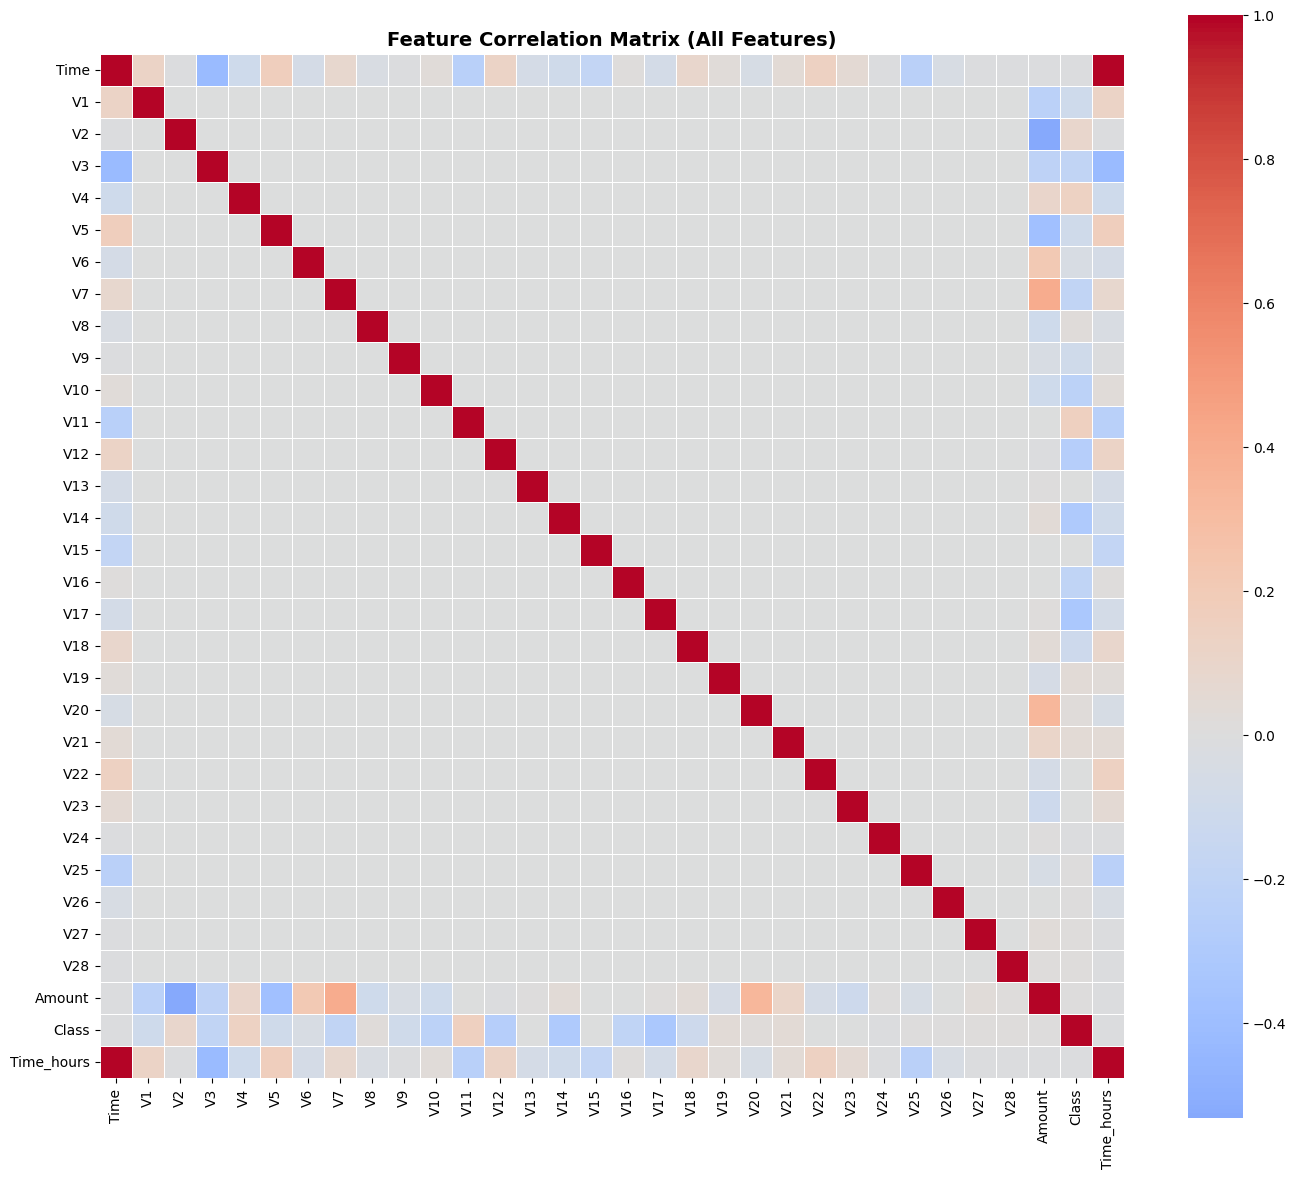


Top Features Correlated with Fraud:
1. V11: 0.1549
2. V4: 0.1334
3. V2: 0.0913
4. V21: 0.0404
5. V19: 0.0348


In [ ]:
correlation_matrix = df.corr()
 
# Plot heatmap for all features
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix (All Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Most correlated with fraud (target)
print("\nTop Features Correlated with Fraud:")
fraud_corr = correlation_matrix['Class'].sort_values(ascending=False)
for i, (feature, corr_val) in enumerate(fraud_corr.items()):
    if feature != 'Class':
        print(f"{i}. {feature}: {corr_val:.4f}")
        if i >= 5:
            break

In [ ]:
if 'Time_hours' in df.columns:
    df = df.drop('Time_hours', axis=1)

## Comments
- The correlation analysis reveals that PCA-transformed features are weak predictors individually:
    + Strongest correlation (V11): 0.1549 — still considered a weak correlation in statistics
    + Next 4 features: 0.0913–0.1334 — weaker
    + Pattern: All correlations are positive but modest, indicating:
        * No single feature is a strong indicator of fraud
        * Fraud detection requires combinations of features
        * The model must learn interactions between features, not rely on individual signals

# III. Preprocessing (IQR Method)
- Definition:
    + Q1: 25th percentile
    + Q2: Median (50th percentile)
    + Q3: 75th percentile
- IQR = Q3 - Q1 measures the spread of the middle 50% of the data
- Outlier boundaries (any value outside this bound is considered an outlier)
    + Lower bound: Q1 - 1.5*IQR
    + Upper bound: Q3 + 1.5*IQR

## 1. Outliers

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


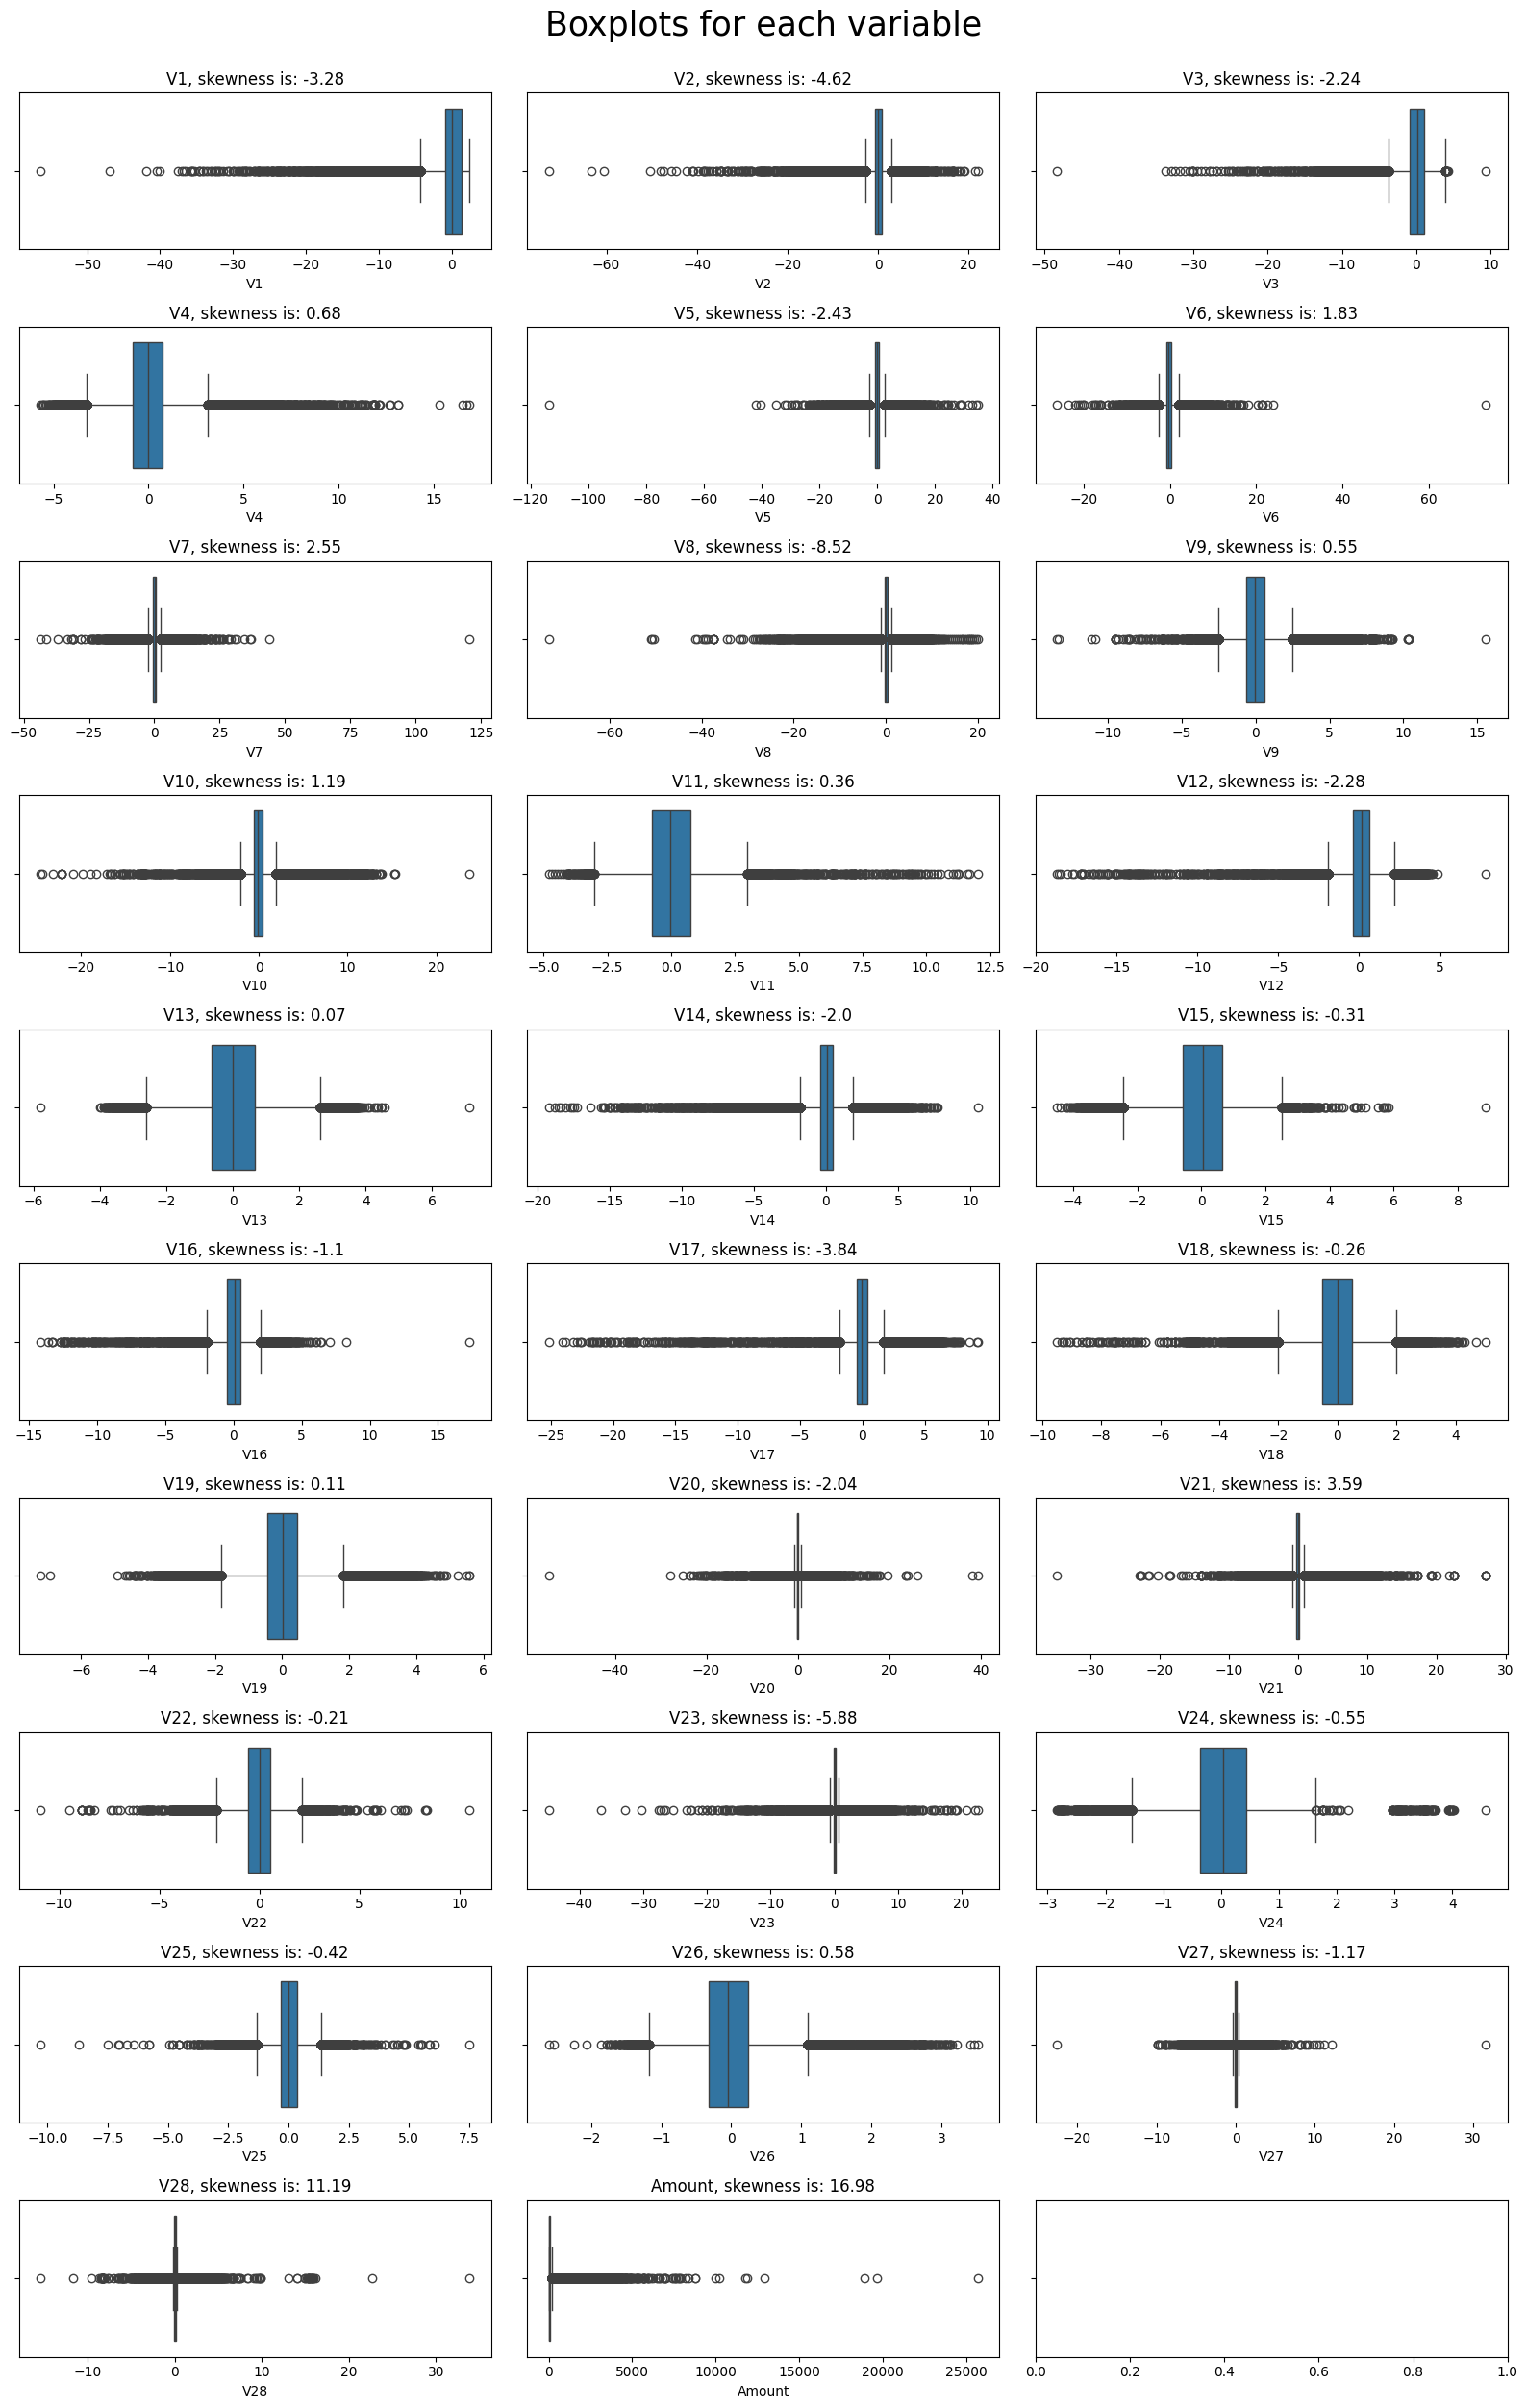

In [ ]:
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,25))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, col in enumerate(columns_list):
        sns.boxplot(data=dataset[col], orient='h', ax=axs[i])
        axs[i].set_title(f"{col}, skewness is: {round(dataset[col].skew(axis = 0, skipna = True),2)}")

columns_list = df.columns.to_list()[1:-1]
print(columns_list)
boxplots_custom(dataset=df, columns_list=columns_list, rows=10, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

## 2. Remove outliers

In [ ]:
def IQR_method (df,n,features):
    outlier_list = []
    
    for column in features:
        # 1st quartile (25%)
        q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        q3 = np.percentile(df[column],75)
        # Interquartile range (IQR)
        iqr = q3 - q1
        # outlier step
        outlier_step = 1.5 * iqr
        # Determining a list of indices of outliers
        outlier_list_rows = df[(df[column] < q1 - outlier_step) | (df[column] > q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_rows)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = [row_id for row_id, freq in outlier_list.items() if freq > n]
    
    out = df.iloc[multiple_outliers].copy()
    out1 = out[out["Class"]  == 1].shape[0]
    out0 = out[out["Class"]  == 0].shape[0]
    print('Total number of deleted outliers belongs to class 1 is:', out1)
    print('Total number of deleted outliers belongs to class 0 is:', out0)
    return multiple_outliers

In [ ]:
# detecting outliers

Outliers_IQR = IQR_method(df, 5,columns_list)

# dropping outliers
df_out = df.drop(Outliers_IQR, axis = 0).reset_index(drop=True)
df_out

Total number of deleted outliers belongs to class 1 is: 413
Total number of deleted outliers belongs to class 0 is: 13959


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270430,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
270431,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
270432,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
270433,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Comments
- Because the number of outliers in both classes is large, we decided not to remove them to avoid losing information.

# IV. Sampling methods
- We used GridSearchCV with 3-fold cross-validation to train the models. If sampling methods are applied to the dataset before training, data leakage may occur.
    + Explanation: Suppose the dataset is resampled before being split by GridSearchCV. In that case, the validation set may contain synthetic or duplicated samples generated from observations in the training folds, leading to data leakage and overly optimistic evaluation results.

- So this section only explain and visualize how sampling methods work. For better result, we should add sampler into pipeline.

In [ ]:
blue_patch = mpatches.Patch(color='blue', label='Legitimate')
red_patch = mpatches.Patch(color='red', label='Fraud')

In [ ]:
columns = df.columns.tolist()
columns.remove('Time')
columns.remove('Class')

In [ ]:
X = df[columns].copy()
y = df["Class"].copy()

In [ ]:
def create_resampled_folds(X, y, sampler):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    train_sets = []
    test_sets = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_res, y_res = sampler.fit_resample(X_train, y_train)

        train_sets.append((X_res, y_res))
        test_sets.append((X_test, y_test))

    return train_sets, test_sets

## 1. Random under-sampling (Not recommended)
- Random Under-Sampling is a technique used to handle imbalanced datasets by randomly removing samples from the majority class.
- Advantages
    + Simple and fast
    + Reduces training time
    + Helps models focus on minority class
- Disadvantages
    + Deletes potentially useful data
    + Can lose important majority-class patterns
    + May reduce model generalization
    + Especially problematic when majority class contains diverse information.

In [ ]:
rus_train, rus_test = create_resampled_folds(X, y, RandomUnderSampler(sampling_strategy=0.5))

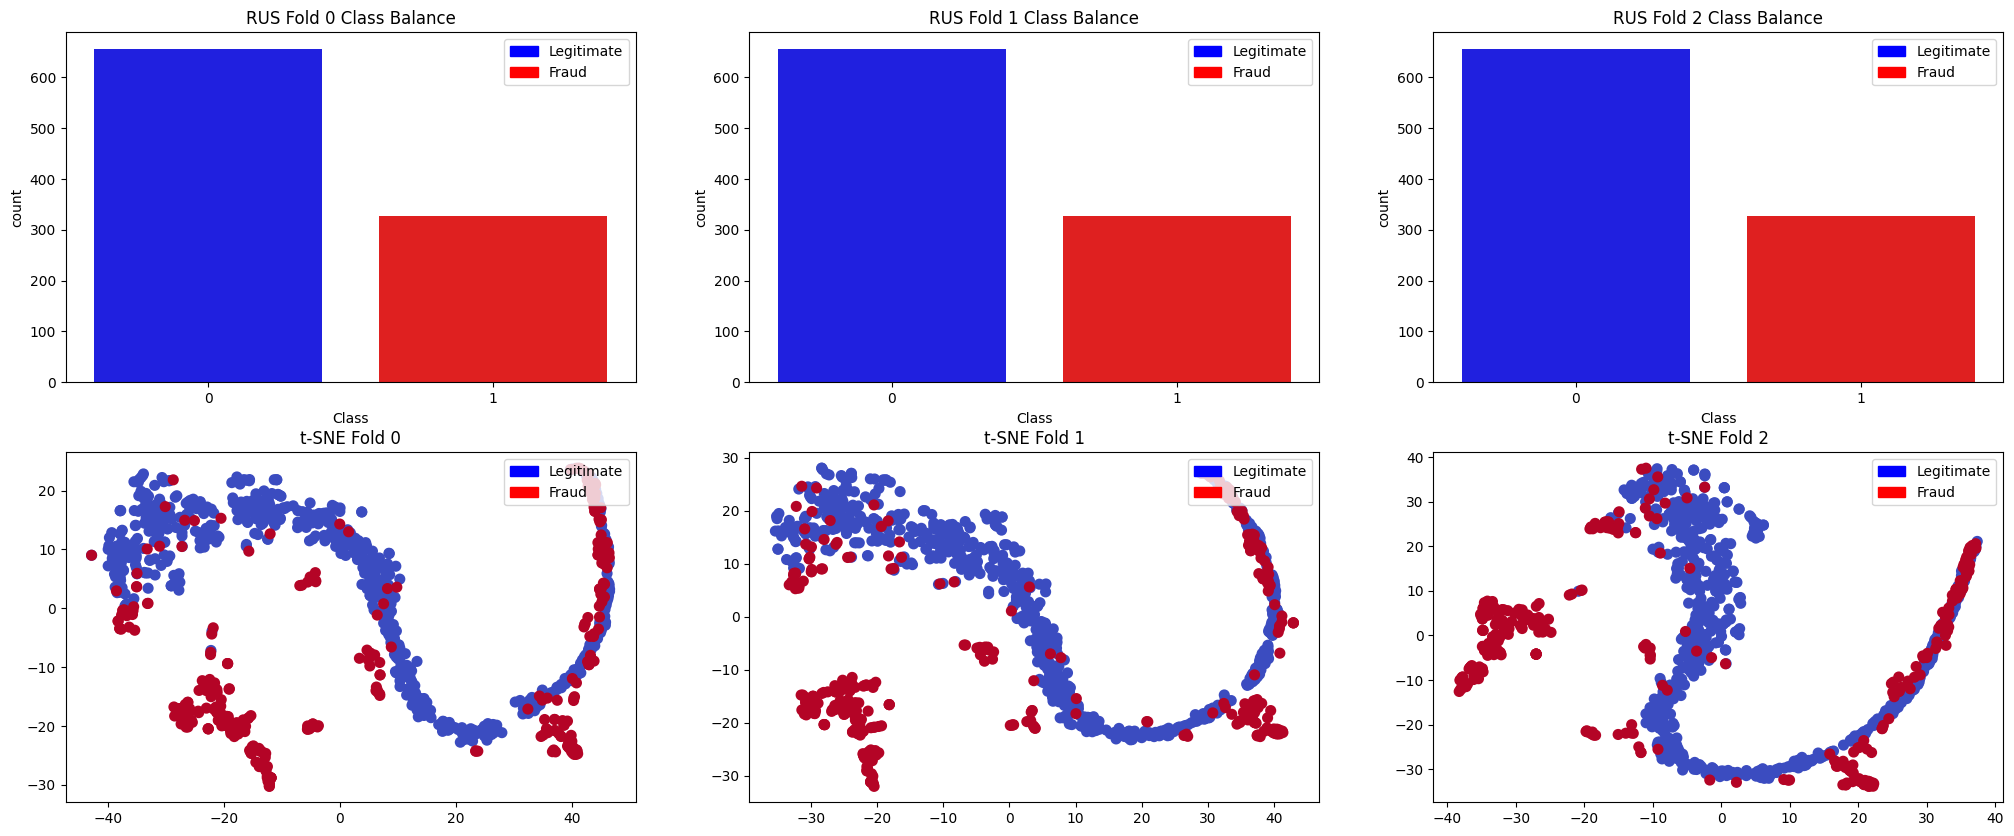

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(rus_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"RUS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles= [blue_patch, red_patch], loc = 'upper right')

## 2. NearMiss under-sampling (Not recommended)
- NearMiss is an under-sampling technique that removes majority-class samples intelligently instead of randomly.
- How NearMiss works:
    + Compute distances between majority and minority samples (Euclidean distance)
    + Keep majority samples closest to minority samples.
- Advantages: 
    + Keeps more informative samples
    + Preserves decision boundary
    + Reduces dataset size	
    + Can improve recall
- Disadvantages:
    + Still an undersampling method so it may remove useful majority information	
    + Distance calculations required (expensive with large dataset)
    + Noisy minority samples distort boundaries
    + Can overfit minority boundary


In [ ]:
nearmiss_train, nearmiss_test = create_resampled_folds(X, y, NearMiss(sampling_strategy=0.5))

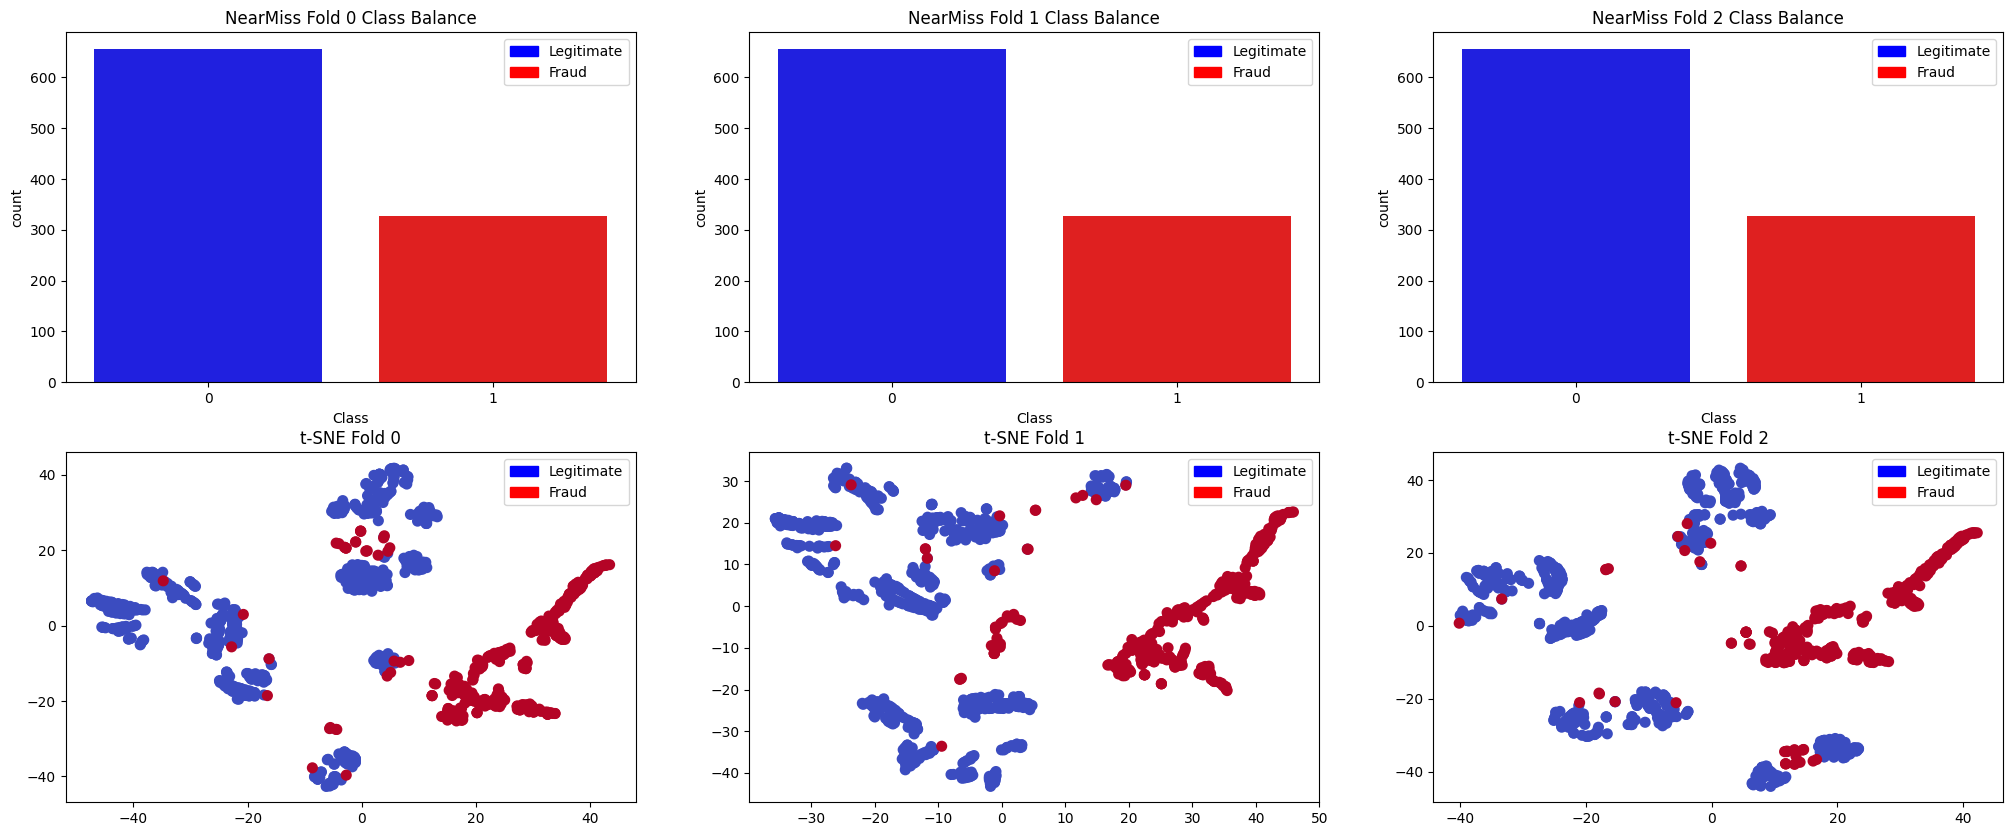

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(nearmiss_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"NearMiss Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 3. Random over-sampling
- Random Over-Sampling balances the dataset by randomly duplicating minority-class samples.
- Advantages
    + Keeps all original data
    + Helps models learn minority patterns better
    + Often improves recall
- Disadvantages
    + Duplicates existing samples (does not create new information)
    + Can increase overfitting
    + Training becomes slower

In [ ]:
ros_train, ros_test = create_resampled_folds(X, y, RandomOverSampler(sampling_strategy=0.2))

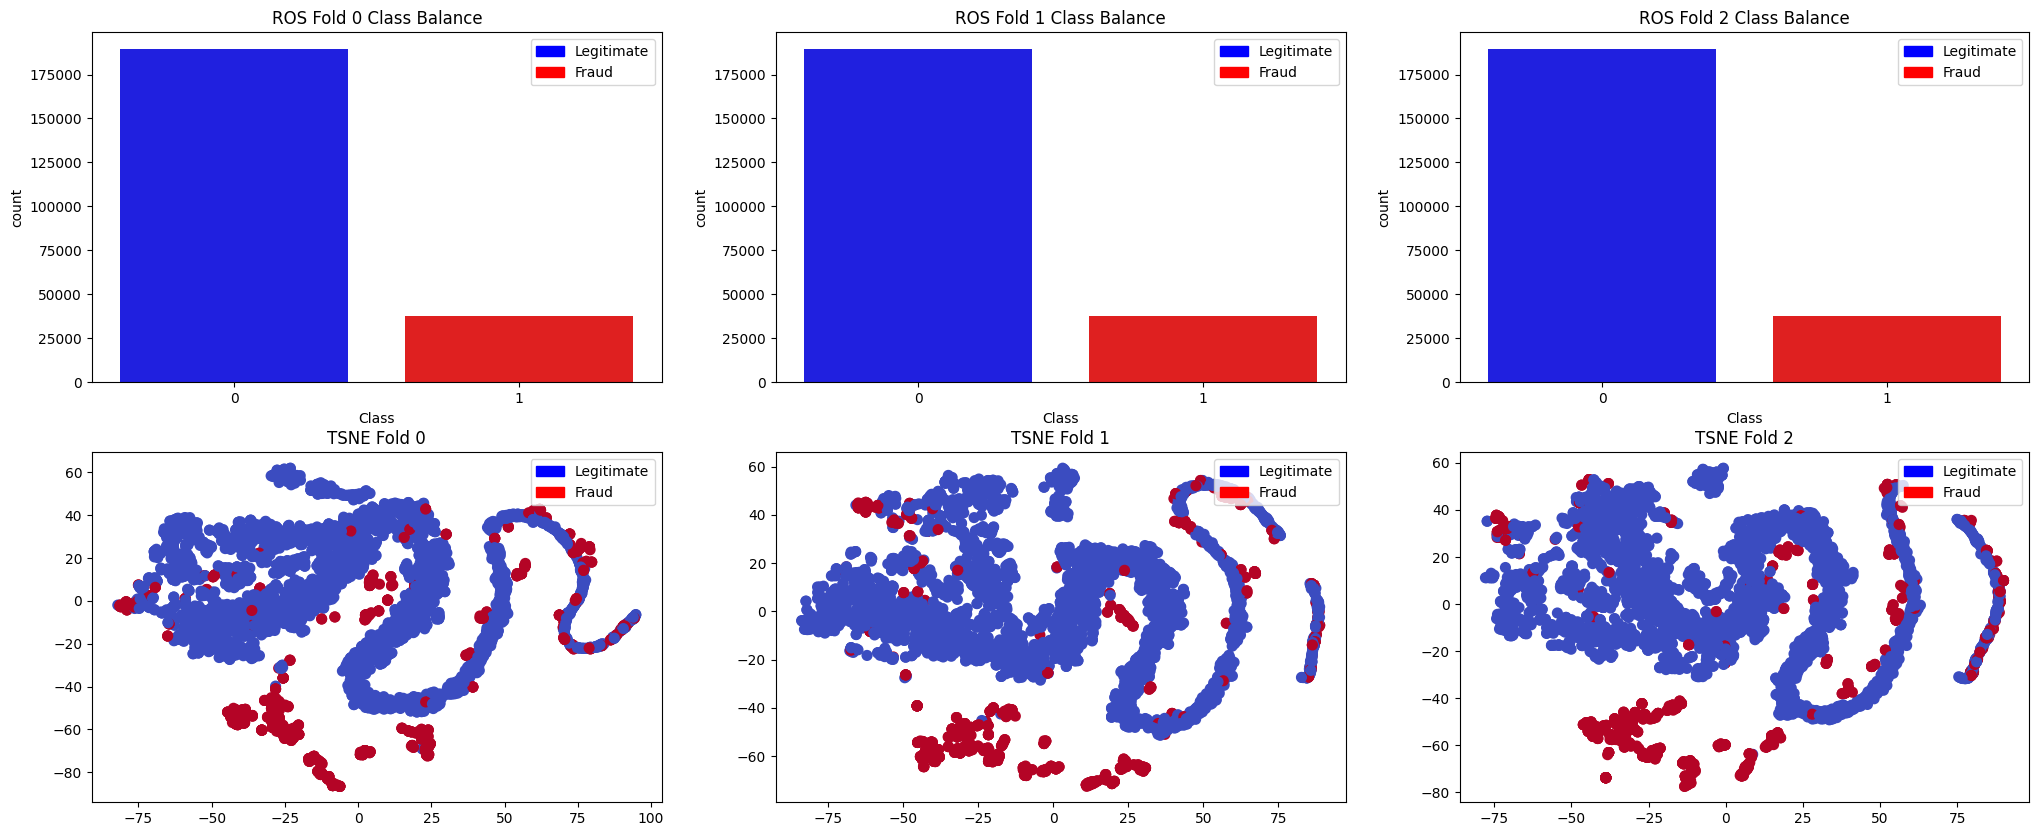

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(ros_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"ROS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 4. SMOTE (Synthetic Minority Over-Sampling Technique)
- SMOTE is an over-sampling technique that creates synthetic minority-class samples instead of duplicating existing ones.
- How SMOTE Works:
    + For a minority sample, find nearest minority neighbors
    + Randomly choose one neighbor
    + Create a synthetic point between them
- Advantages:
    + Reduces overfitting
    + Generates new information
    + Improves minority learning
    + Often improves recall/F1
- Disadvantages:
    + Can create unrealistic samples
    + Noisy minority samples create noisy synthetic points
    + Creates overlap between classes (blur class boudaries)
    + Increases training time

In [ ]:
smote_train, smote_test = create_resampled_folds(X, y, SMOTE(sampling_strategy=0.2))

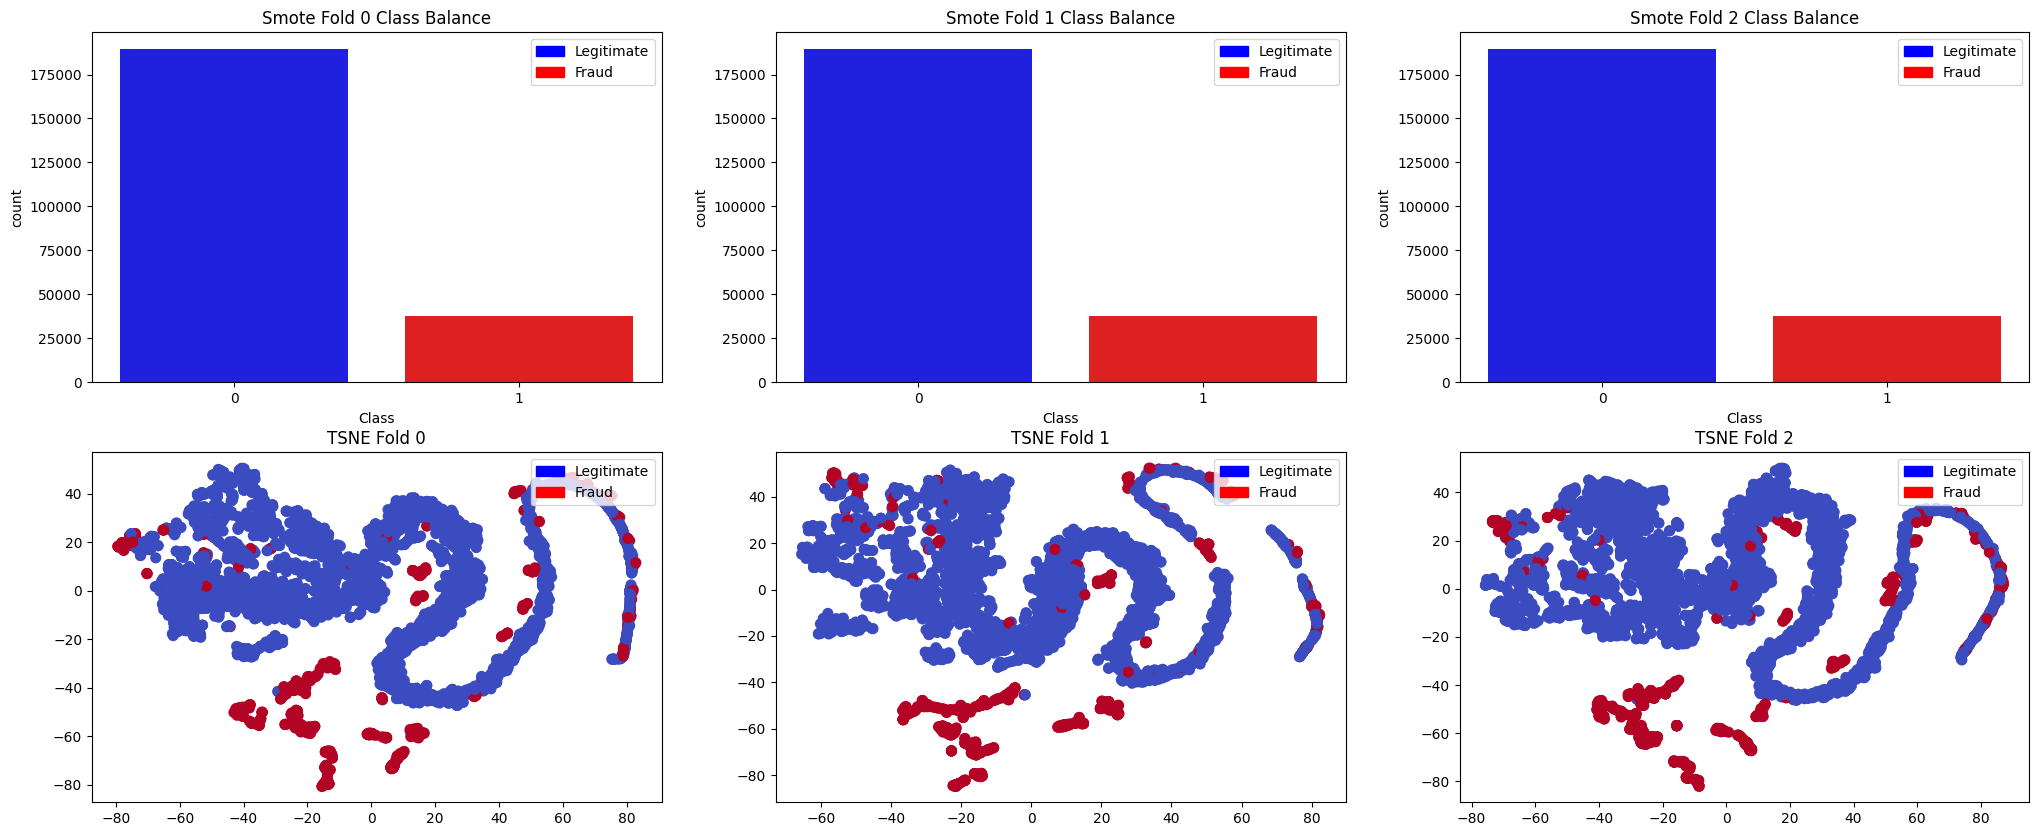

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smote_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"Smote Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 5. Combine Tomek and SMOTE
- SMOTETomek combines: SMOTE (oversampling) and Tomek Links (cleaning undersampling)
- How Tomek works? For 2 samples from different class, if they are each other's nearest neighbor, Tomek will remove those ambiguous samples.
- Improvement from SMOTE:
    + Tomek cleans noisy boundaries (better class separation)
- Trade off: 
    + Expensive computation cost (two-stage process)
    + May remove useful samples which are on boundaries

In [ ]:
smotetomek_train, smotetomek_test = create_resampled_folds(X, y, SMOTETomek(sampling_strategy=0.2))

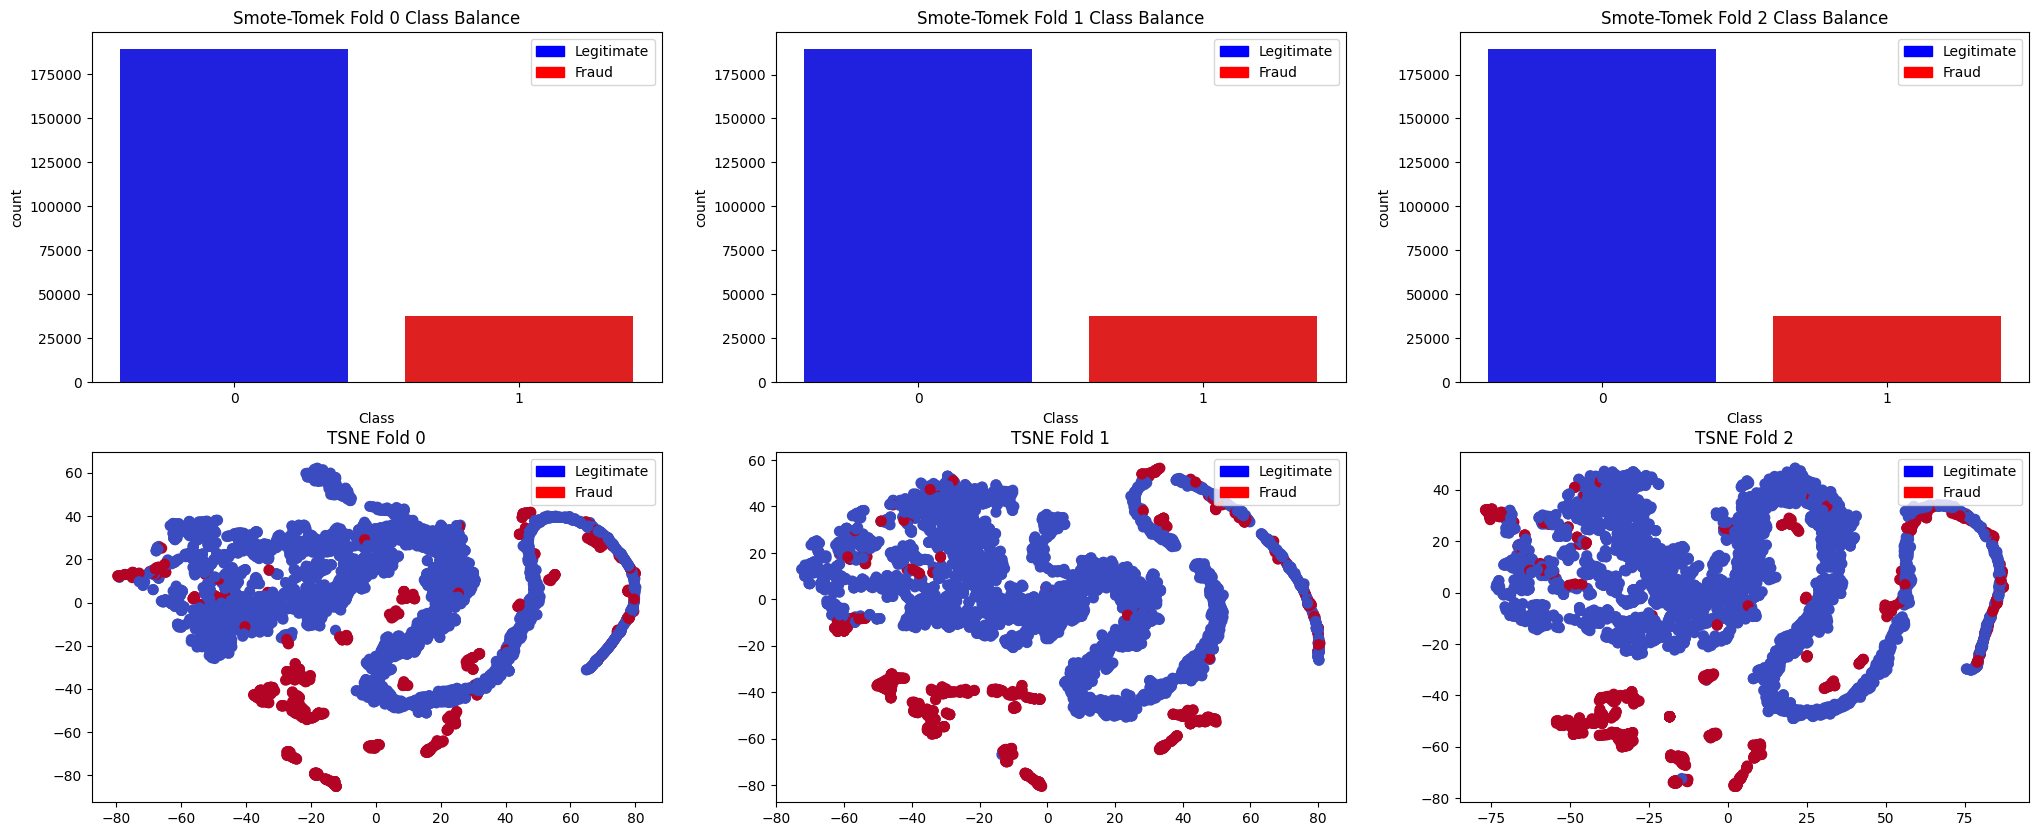

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smotetomek_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"Smote-Tomek Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

# V. Training models
## Model Selection

We selected several machine learning models with different learning characteristics to compare their effectiveness on the fraud detection task.

- **Logistic Regression** was chosen as a simple and interpretable baseline model. It performs well on linearly separable data and provides probability outputs that are useful for threshold tuning.

- **LinearSVC** was selected because Support Vector Machines are effective for high-dimensional datasets. The linear version is computationally efficient and can learn strong decision boundaries for binary classification.

- **Random Forest** was chosen because it is an ensemble tree-based model capable of capturing nonlinear relationships and feature interactions. It is also robust to noise and less sensitive to outliers.

- **XGBoost** was selected due to its strong performance on tabular and imbalanced datasets. Its boosting mechanism allows the model to sequentially correct previous errors, often leading to superior predictive performance in fraud detection tasks.
---
## Evaluation Metric

We used **Average Precision (AP)** as the main evaluation metric because the dataset is highly imbalanced. Accuracy is not reliable in this scenario since a model can achieve high accuracy by predicting most transactions as legitimate.

Average Precision summarizes the Precision-Recall curve and evaluates the model’s ability to correctly rank fraudulent transactions higher than legitimate ones across different thresholds. This metric is more informative for fraud detection because it emphasizes performance on the minority (fraud) class.

---
## Spliting training and testing dataset

We used train_test_split with stratify=y to preserve the class distribution when splitting the dataset into training and testing sets.

---
## Cross Validation

We used StratifiedKFold(n_splits=3, shuffle=True, random_state=42) to split the training set into 3 folds, with each fold preserving the class distribution.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

## 1. Building pipeline

In [ ]:
def run_model(model_sampler, model, sampler, param_grid, X_train, X_test, y_train, y_test):
    steps = []
    steps.append(('scaler', RobustScaler()))
    if sampler is not None:
        steps.append(('sampler', sampler))

    steps.append(('clf', model))

    pipe = Pipeline(steps)
    
    start = time.time()
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='average_precision',
        n_jobs=-1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    )
    grid.fit(X_train, y_train)
    
    end = time.time()
    print("Best Params:", grid.best_params_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    trained_time = end - start
    recall_s = recall_score(y_test, y_pred)
    pre_s = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Trained time: {trained_time:.2f}s")
    print("Recall:", recall_s)
    print("Precision:", pre_s)
    print("F1-score: ", f1)
    print("\n")

    return {"model_name":model_sampler,
            "model": best_model,
            "model_score": grid.best_score_, 
            "best_params":grid.best_params_, 
            "recall_score":recall_s,
            "precision_score":pre_s,
            "f1-score":f1,
            "time": round(trained_time,2)}


## 2. Training model
### a. Logistic Regression

In [ ]:
results = []

In [ ]:
params_grid_log = {"clf__penalty": ['l2'], 
                   'clf__C': [0.01, 0.1, 1, 10, 100]}
logreg = run_model("LogisticRegression + balanced class_weight", LogisticRegression(solver= 'liblinear', class_weight='balanced', max_iter=3000), 
                   None, 
                   params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg)

Best Params: {'clf__C': 0.1, 'clf__penalty': 'l2'}
Trained time: 47.05s
Recall: 0.8861788617886179
Precision: 0.060825892857142856
F1-score:  0.11383812010443864




In [ ]:
logreg_ros = run_model("LogisticRegression + Random Over Sampling",LogisticRegression(solver= 'liblinear', max_iter=3000), 
                       RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_ros)

Best Params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Trained time: 32.10s
Recall: 0.8536585365853658
Precision: 0.24249422632794457
F1-score:  0.3776978417266187




In [ ]:
logreg_rus = run_model("LogisticRegression + Random Under Sampling",LogisticRegression(solver= 'liblinear', max_iter=3000), 
                       RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_rus)

Best Params: {'clf__C': 10, 'clf__penalty': 'l2'}
Trained time: 2.37s
Recall: 0.8943089430894309
Precision: 0.07447528774542993
F1-score:  0.1375




In [ ]:
logreg_nm = run_model("LogisticRegression + Nearmiss",LogisticRegression(solver= 'liblinear', max_iter=3000), 
                      NearMiss(sampling_strategy=0.5), 
                      params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_nm)

Best Params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Trained time: 6.13s
Recall: 0.8780487804878049
Precision: 0.004304675355733588
F1-score:  0.008567348881485007




In [ ]:
logreg_smotetomek = run_model("LogisticRegression + SmoteTomek",LogisticRegression(solver= 'liblinear', max_iter=3000), 
                              SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                              params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_smotetomek)

Best Params: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Trained time: 1439.96s
Recall: 0.8617886178861789
Precision: 0.2222222222222222
F1-score:  0.35333333333333333




### b. Linear SVC

In [ ]:
params_grid_linear_svc = {'clf__C': [0.01, 0.1, 1, 10]}
lsvc = run_model("LinearSVC + balanced class_weight", LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
                 None,
                 params_grid_linear_svc, X_train, X_test, y_train, y_test)
results.append(lsvc)


Best Params: {'clf__C': 0.01}
Trained time: 25.57s
Recall: 0.8861788617886179
Precision: 0.07204230006609386
F1-score:  0.1332518337408313




In [ ]:
lsvc_ros = run_model("LinearSVC + Random Over Sampling", LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
                 RandomOverSampler(sampling_strategy=0.2, random_state=42),
                 params_grid_linear_svc, X_train, X_test, y_train, y_test)
results.append(lsvc_ros)

Best Params: {'clf__C': 0.1}
Trained time: 23.01s
Recall: 0.8861788617886179
Precision: 0.07110241356816699
F1-score:  0.1316425120772947




In [ ]:
lsvc_rus = run_model("LinearSVC + Random Under Sampling", LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
                 RandomUnderSampler(sampling_strategy=0.5, random_state=42),
                 params_grid_linear_svc, X_train, X_test, y_train, y_test)
results.append(lsvc_rus)

Best Params: {'clf__C': 1}
Trained time: 2.13s
Recall: 0.8943089430894309
Precision: 0.05071461502996773
F1-score:  0.09598603839441536




In [ ]:
lsvc_nm = run_model("LinearSVC + Nearmiss", LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
                 NearMiss(sampling_strategy=0.5), 
                 params_grid_linear_svc, X_train, X_test, y_train, y_test)
results.append(lsvc_nm)

Best Params: {'clf__C': 10}
Trained time: 5.16s
Recall: 0.943089430894309
Precision: 0.003043101865211574
F1-score:  0.006066628314418702




In [ ]:
lsvc_smotetomek = run_model("LinearSVC + SmoteTomek", LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
                 SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                 params_grid_linear_svc, X_train, X_test, y_train, y_test)
results.append(lsvc_smotetomek)

Best Params: {'clf__C': 0.01}
Trained time: 1177.67s
Recall: 0.8780487804878049
Precision: 0.06792452830188679
F1-score:  0.12609457092819615




### c. Random Forest

In [ ]:
params_grid_rf = {
    'clf__n_estimators': [150, 300],
    'clf__max_depth':  [5, 10],
    "clf__min_samples_leaf": [50, 100, 300],
}
rf = run_model("RandomForest + balanced class_weight",RandomForestClassifier(class_weight='balanced', random_state=42), 
               None, 
               params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 2705.56s
Recall: 0.8617886178861789
Precision: 0.6794871794871795
F1-score:  0.7598566308243727




In [ ]:
rf_ros = run_model("RandomForest + Random Over Sampling",RandomForestClassifier(random_state=42), 
                   RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_ros)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 3272.07s
Recall: 0.8536585365853658
Precision: 0.6818181818181818
F1-score:  0.7581227436823105




In [ ]:
rf_rus = run_model("RandomForest + Random Under Sampling", RandomForestClassifier(random_state=42), 
                   RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_rus)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 18.55s
Recall: 0.8455284552845529
Precision: 0.4622222222222222
F1-score:  0.5977011494252874




In [ ]:
rf_nm = run_model("RandomForest + Nearmiss",RandomForestClassifier(random_state=42), 
                  NearMiss(sampling_strategy=0.5), 
                  params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_nm)

Best Params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 300}
Trained time: 23.18s
Recall: 0.8943089430894309
Precision: 0.005284396617986164
F1-score:  0.010506709967047136




In [ ]:
rf_smotetomek = run_model("RandomForest + SmoteTomek",RandomForestClassifier(random_state=42), 
                     SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')),
                     params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_smotetomek)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 300}
Trained time: 7042.61s
Recall: 0.8617886178861789
Precision: 0.6309523809523809
F1-score:  0.7285223367697594




### d. XGBoost

In [ ]:
params_grid_xgb = {
    'clf__scale_pos_weight': [10, 15],  
    'clf__min_child_weight': [2, 5, 7],        
    'clf__gamma': [0.3, 0.5, 1.0],         
    'clf__max_depth': [5, 7],
    'clf__learning_rate': [0.01, 0.05],  
    'clf__n_estimators': [200, 300]
}

xgb = run_model("XGBoost", XGBClassifier(random_state = 42, eval_metric = 'logloss'),
                None, 
                params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb)

Best Params: {'clf__gamma': 0.3, 'clf__learning_rate': 0.05, 'clf__max_depth': 7, 'clf__min_child_weight': 5, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 10}
Trained time: 1086.61s
Recall: 0.7967479674796748
Precision: 0.8990825688073395
F1-score:  0.8448275862068966




In [ ]:
xgb_ros = run_model("XGBoost + Random Over Sampling", XGBClassifier(random_state = 42, eval_metric = 'logloss'),
                    RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                    params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb_ros)

Best Params: {'clf__gamma': 0.5, 'clf__learning_rate': 0.05, 'clf__max_depth': 7, 'clf__min_child_weight': 7, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 10}
Trained time: 1450.67s
Recall: 0.8455284552845529
Precision: 0.8455284552845529
F1-score:  0.8455284552845529




In [ ]:
xgb_rus = run_model("XGBoost + Random Under Sampling", XGBClassifier(random_state = 42, eval_metric = 'logloss'),
                    RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                    params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb_rus)

Best Params: {'clf__gamma': 0.3, 'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__min_child_weight': 5, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 10}
Trained time: 194.08s
Recall: 0.9105691056910569
Precision: 0.04205782951558393
F1-score:  0.08040201005025126




In [ ]:
xgb_nm = run_model("XGBoost + Nearmiss", XGBClassifier(random_state = 42, eval_metric = 'logloss'),
                    NearMiss(sampling_strategy=0.5), 
                    params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb_nm)

Best Params: {'clf__gamma': 0.5, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__min_child_weight': 7, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 15}
Trained time: 244.40s
Recall: 1.0
Precision: 0.0019018755895041208
F1-score:  0.003796530650040126




In [ ]:
xgb_smotetomek = run_model("XGBoost + SmoteTomek", XGBClassifier(random_state = 42, eval_metric = 'logloss'),
                            SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')),
                            params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb_smotetomek)

KeyboardInterrupt: 

## 3. Model comparison
- There are 2 problems in this task:
    + The cost of missing a fraudulent transaction is more severe than the cost of mistakenly capturing the legitimate one
    + But we can't either ignore the convinience/comfort of the customers
- Choosing model with high recall and acceptable f1 scores will solve problems
- In this notebook, the overall score is computed based on recall and F1-score with weights of 0.8 and 0.2, respectively.

In [ ]:
results_df = pd.DataFrame(results)
results_df["scaled_score"] = 0.8*results_df.loc[:, 'recall_score'] + 0.2*results_df.loc[:,'precision_score']
results_df = results_df.sort_values(by=['scaled_score'], ascending=[False]).reset_index(drop=True)
display_results = results_df.drop(columns=['model', 'model_score', 'best_params'])
display_results

# VI. Explainable AI - SHAP Analysis

## Overview
After identifying the best-performing models, we use **SHAP (SHapley Additive exPlanations)** to understand which features drive model predictions for fraud detection. SHAP provides model-agnostic explanations by calculating the contribution of each feature to individual predictions.

## Key Considerations
**Dataset Limitation**: The dataset uses anonymized PCA-transformed variables (V1–V28). Therefore, SHAP explanations identify influential latent components rather than business-interpretable features. In a real-world scenario with original features (e.g., transaction location, merchant category, time of day), SHAP would reveal directly actionable insights such as "transactions from high-risk countries" or "unusually high amounts." Here, we can identify *patterns* (e.g., "latent component V15 strongly indicates fraud") but cannot directly map these back to business meanings without access to the original feature space.

## Explanations Provided
1. **SHAP Summary Plot (Bar)**: Shows the global feature importance across all predictions
2. **SHAP Dependence Plots**: Illustrates how feature values influence model output for top features
3. **SHAP Force Plots**: Individual prediction explanations showing how features push the prediction toward fraud or legitimate
4. **SHAP Decision Plots**: Visualizes the decision-making process across multiple samples

In [ ]:
np.random.seed(42)
sample_indices = np.random.choice(X_test.shape[0], size=min(5000, X_test.shape[0]), replace=False)
X_test_sample = X_test.iloc[sample_indices].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_indices].reset_index(drop=True)

print(f"Test sample size: {X_test_sample.shape[0]}")
print(f"Fraud cases in sample: {y_test_sample.sum()} ({100*y_test_sample.sum()/len(y_test_sample):.2f}%)")
print(f"Features shape: {X_test_sample.shape}")

In [ ]:
def explain_model(model, X_test_sample):
    scaler = model.named_steps['scaler']
    classifier = model.named_steps['clf']
    
    # Store feature names BEFORE transform (important!)
    feature_names = X_test_sample.columns.tolist()

    X_sample_transformed = scaler.transform(X_test_sample)
    
    explainer = shap.TreeExplainer(classifier)
    shap_vals = explainer.shap_values(X_sample_transformed)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
        
    return explainer, shap_vals, X_sample_transformed, feature_names

In [ ]:
best_model = results_df.loc[0, 'model']
best_model_name = results_df.loc[0, 'model_name']
explainer, best_shap_values, X_sample_transformed, feature_names = explain_model(best_model, X_test_sample)
# Get the base value (expected model output)
base_value = explainer.expected_value if hasattr(explainer, 'expected_value') else 0

## 1. SHAP Summary Plots (Feature Importance)

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(best_shap_values, X_sample_transformed, show=False, feature_names=feature_names, plot_type='bar')
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('mean(|SHAP value|) (average impact on model output)', fontsize=11)
plt.tight_layout()
plt.show()
print(f"\n{best_model_name}: Top 10 most important features for fraud prediction")

## 2. SHAP Dependence Plots (Feature Impact Analysis)

In [ ]:
# Plot dependence for top 4 features
# Get feature importance ranking
feature_importance = np.abs(best_shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature_idx in enumerate(top_features_idx):
    feature_name = feature_names[feature_idx]  # ✅ Use stored feature_names
    ax = axes[idx]
    
    shap.dependence_plot(feature_idx, best_shap_values, X_sample_transformed, 
                        feature_names=feature_names,  # ✅ Use stored feature_names
                        ax=ax, show=False)
    ax.set_title(f'{feature_name} - SHAP Dependence Plot', fontsize=11, fontweight='bold')

plt.suptitle(f'Top 4 Features - {best_model_name}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Interpretation: Each dot represents a transaction.")
print("X-axis: Feature value | Y-axis: SHAP value (contribution to fraud prediction)")
print("Red/Blue color: Interaction with another important feature")

## 3. SHAP Force Plots (Individual Prediction Explanations)

In [ ]:
# Find fraud and non-fraud examples
fraud_idx = np.where(y_test_sample == 1)[0]
legitimate_idx = np.where(y_test_sample == 0)[0]

print(f"Fraud examples: {len(fraud_idx)}, Non-fraud examples: {len(legitimate_idx)}")

# Get one example from each class
fraud_example_idx = fraud_idx[0] 
legitimate_example_idx = legitimate_idx[0]

In [ ]:
print(f"Fraud transaction example")
print(f"Actual Class: Fraud (1)")
force_plot_fraud = shap.force_plot(base_value, best_shap_values[fraud_example_idx], 
                                    X_sample_transformed[fraud_example_idx],  # ✅ Direct numpy indexing
                                    feature_names=feature_names,  # ✅ Use stored feature_names
                                    matplotlib=True)
plt.title('Force Plot - Fraudulent Transaction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Legitimate transaction example")
print(f"Actual Class: Legitimate (0)")
force_plot_legit = shap.force_plot(base_value, best_shap_values[legitimate_example_idx], 
                                    X_sample_transformed[legitimate_example_idx],  # ✅ Direct numpy indexing
                                    feature_names=feature_names,  # ✅ Use stored feature_names
                                    matplotlib=True)
plt.title('Force Plot - Legitimate Transaction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. SHAP Decision Plots (Model Decision Path)

In [ ]:
# Separate fraud and non-fraud samples
fraud_mask = y_test_sample == 1
legitimate_mask = y_test_sample == 0

# Plot decision plot for fraud cases (if available)
print("Decision Plot - Fraudulent Transactions")
fig = plt.figure(figsize=(14, 8))
shap.decision_plot(base_value, best_shap_values[fraud_mask][:min(500, fraud_mask.sum())], 
                    X_sample_transformed[fraud_mask][:min(500, fraud_mask.sum())],
                    feature_names=feature_names,  # ✅ Use stored feature_names
                    show=False)
plt.title(f'Decision Plot - Fraudulent Transactions (Best Model: {best_model_name})', 
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\nDecision Plot - Legitimate Transactions")
fig = plt.figure(figsize=(14, 8))
shap.decision_plot(base_value, best_shap_values[legitimate_mask][:min(500, legitimate_mask.sum())], 
                    X_sample_transformed[legitimate_mask][:min(500, legitimate_mask.sum())],
                    feature_names=feature_names,  # ✅ Use stored feature_names
                    show=False)
plt.title(f'Decision Plot - Legitimate Transactions (Best Model: {best_model_name})', 
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Key Insights from SHAP Analysis

### Interpretation Guide
- **SHAP Value**: Represents the contribution of a feature to pushing the prediction away from the base value (expected model output)
  - Positive SHAP → pushes prediction toward fraud (higher probability)
  - Negative SHAP → pushes prediction toward legitimate (lower probability)

- **Feature Importance**: Features with larger average |SHAP| values are more influential in the model's decision

- **Dependence**: Shows how changes in feature values affect predictions; helps identify non-linear relationships

### Business Implications
1. **Most Influential Features**: The top features identified by SHAP represent latent patterns in the data that most strongly indicate fraud
2. **Individual Explanations**: For any transaction flagged by the model, SHAP can explain which features contributed to the decision
3. **Model Validation**: If the top features make business sense (even after PCA transformation), it increases confidence in the model
4. **Debugging**: Unusual SHAP patterns might indicate:
   - Data quality issues
   - Model overfitting
   - Distribution shifts in new data

# VII. Threshold Tunning for best model

In [ ]:
def predict_with_threshold(model, X, threshold):
    original_prob = model.predict_proba(X)[:, 1]
    threshold_classify = (original_prob >= threshold).astype(int)
    y_pred = threshold_classify.astype(int)
    return y_pred

def evaluate_threshold(model_sampler, model, X_test, y_test, threshold):
    y_pred = predict_with_threshold(model, X_test, threshold)
    
    return {
        "model_name": model_sampler,
        "threshold": threshold,
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

def threshold_curve(model_sampler, model, X_test, y_test, thresholds=np.linspace(0.1, 0.9, 9)):
    tunning_scores = []
    
    for t in thresholds:
        res = evaluate_threshold(model_sampler, model, X_test, y_test, t)
        tunning_scores.append(res)
    
    return tunning_scores

In [ ]:
models = {
    "Random Forest + class weight balanced": rf['model'],
    "Random Forest + Random Over Sampling": rf_ros['model'],
    "Random Forest + SmoteTomek": rf_smotetomek['model'],
    "XGBoost + Random Over Sampling": xgb_ros['model'],
    "XGBoost + SmoteTomek": xgb_smotetomek['model']
}

fig, axes = plt.subplots(1, 5, figsize = (25, 4))
for i, (model_name, model) in enumerate(models.items()):
    ax = axes[i]
    tunning_scores = threshold_curve(
        model_sampler=model_name,
        model=model,
        X_test=X_test,
        y_test=y_test
    )

    thresholds = [r["threshold"] for r in tunning_scores]
    recalls = [r["recall"] for r in tunning_scores]
    precisions = [r["precision"] for r in tunning_scores]
    f1s = [r["f1"] for r in tunning_scores]
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, f1s, label="F1-score")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend()
    ax.set_title(f"{model_name}")
    ax.grid(True)

## Comments
- For Random Forest + Class_weigth balanced:
    + If we increase threshold to 0.6, the recall score will drop sharply
    + So we'll keep the default threshold
- For Random Forest + Random Over Sampling:
    + If we increas threshold to 0.6, the f1-score and precision score will increase strongly while the recall score decrease slightly
    + So we'll increase this model's threshold to 0.6
- For Random Forest + SmoteTomek:
    + If we increas threshold to 0.6, the f1-score and precision score will rise while the recall score remain stable
    + So we'll increase this model's threshold to 0.6
- For XGBoost + Random Over Sampling:
    + When the threshold exceeds 0.5, the recall score will fall and the f1-score unchange
    + So we'll keep the default threshold
- For XGBoost + SmoteTomek:
    + Even if we increase the threshold to 0.7, the recall still doesn't change, but there is an improvement in f1 and precision score
    + So we'll increase the threshold of model to 0.7

In [ ]:
scores = []
threshold = [0.5, 0.6, 0.6, 0.5, 0.7]
for (model_name, model), t in zip(models.items(), threshold):
    score = evaluate_threshold(model_sampler=model_name, 
                               model=model, 
                               X_test=X_test, 
                               y_test = y_test,
                               threshold=t)
    scores.append(score)

scores_df = pd.DataFrame(scores)
scores_df.drop(columns = ['confusion_matrix'])
scores_df['scaled_score'] = 0.8*scores_df['recall'] + 0.2*scores_df['f1']
scores_df = scores_df.sort_values(by=['scaled_score'], ascending=[False]).reset_index(drop=True)
scores_df


# VIII. Conclusion
1. **Evaluating Models (4 Models × 5 Sampling Methods)**

    In this section, we compare the performance of four machine learning models—Logistic Regression, LinearSVC, Random Forest, and XGBoost—each paired with five different sampling strategies to handle class imbalance.

    Model and Sampling Strategy Overview
        - The evaluation covers 20 model-sampling combinations:
            + Models: Logistic Regression, LinearSVC, Random Forest, XGBoost
            + Sampling strategies:
                + Baseline (class_weight balancing)
                + Random Over-Sampling (ROS)
                + Random Under-Sampling (RUS)
                + NearMiss
                + SMOTE + Tomek Links

    Worst Performers - NearMiss & Random Under-Sampling:
    - Random Under-Sampling (RUS) - Not Recommended
        + Limitation: Removes majority class samples, leading to significant data loss (284,315 → ~984 samples)
        + Impact: Model loses valuable patterns in legitimate transactions; reduced generalization
        + Trade-off: Faster training but unreliable predictions; not suitable for production
        + Result: Consistently ranked in bottom tier across all models

    - NearMiss - Limited Effectiveness
        + Limitation: Removes majority class samples closest to minority class, creating artificial decision boundaries
        + Impact: Can eliminate important edge cases from legitimate class; biases model toward minority class
        + Trade-off: Smarter than RUS but still removes data; creates artificial patterns
        + Result: Moderate performance but underperforms compared to over-sampling and synthesis methods

2. **Evaluating Final Models (Threshold Tuning)**

    After selecting the best-performing models from Section 1, we applied threshold tuning to optimize fraud detection performance based on business requirements.

    Threshold Tuning Process Overview
    - Why Threshold Tuning Matters:
        + Default threshold = 0.5 (model predicts fraud if P(fraud) ≥ 0.5)
        + Lowering threshold → higher recall (catch more fraud) but more false alarms (lower precision)
        + Raising threshold → lower false alarms (higher precision) but miss some fraud (lower recall)

    - Approach:
        + Tested thresholds from 0.1 to 0.9 (in 0.1 increments)
        + Measured recall, precision, and F1-score at each threshold
        + Selected final thresholds that maximize the weighted score (0.8×Recall + 0.2×F1)
        + This weighting reflects business priority: catching fraud is 4× more important than reducing false alarms


# IX. References
- Janio Martinez Bachmann. (2019). Credit Fraud || Dealing with Imbalanced Datasets: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Gabriel Preda. (2021). Credit Card Fraud Detection Predictive Models: https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models